In [103]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
#Upload data set
#company_char = pd.read_csv('../datasets/Cleaned_DS_Jobs.csv')

In [107]:
df1 = pd.read_csv("../datasets/Cleaned_DS_Jobs.csv")
df2 = pd.read_csv("../datasets/data_cleaned_2021.csv")

In [108]:
df1.columns = df1.columns.str.lower()
df2.columns = df2.columns.str.lower()

In [109]:
common_cols = list(set(df1.columns).intersection(set(df2.columns)))
print("Common columns:", common_cols)

Common columns: ['excel', 'type of ownership', 'revenue', 'job description', 'tableau', 'aws', 'headquarters', 'hadoop', 'location', 'size', 'industry', 'company name', 'python', 'spark', 'job title', 'sector', 'salary estimate', 'rating']


In [110]:
company_char = pd.merge(df1, df2, on=common_cols, how="outer")
print(company_char.shape)

(1402, 51)


In [111]:
#View first 5 rows of your data
company_char.head()

,job title,salary estimate,job description,rating,company name,location,headquarters,size,type of ownership,industry,...,pytorch,scikit,tensor,bi,flink,mongo,google_an,job_title_sim,seniority_by_title,degree
0,Data Scientist,122-146,About Our AI/ML Team\n\nOur mission is to buil...,0.0,Point72 Ventures,"Palo Alto, CA",-1,-1,-1,-1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,ELISA RESEARCH SCIENTIST (CV-15),90-109,"Covaxx, a subsidiary of the UBI Group, has joi...",0.0,Covid-19 Search Partners,"Hauppauge, NY",-1,-1,-1,-1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Data Scientist,105-167,Job Description\nBecome a thought leader withi...,0.0,JKGT,"San Francisco, CA",-1,-1,-1,-1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Data Scientist,122-146,Job Overview: The Data Scientist is a key memb...,0.0,Hatch Data Inc,"San Francisco, CA",-1,-1,-1,-1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Data Scientist,122-146,Job Overview: The Data Scientist is a key memb...,0.0,Hatch Data Inc,"San Francisco, CA",-1,-1,-1,-1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [112]:
#Identify the data types for each columns within your dataframe
company_char.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1402 entries, 0 to 1401
Data columns (total 51 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   job title           1402 non-null   object 
 1   salary estimate     1402 non-null   object 
 2   job description     1402 non-null   object 
 3   rating              1402 non-null   float64
 4   company name        1402 non-null   object 
 5   location            1402 non-null   object 
 6   headquarters        1402 non-null   object 
 7   size                1402 non-null   object 
 8   type of ownership   1402 non-null   object 
 9   industry            1402 non-null   object 
 10  sector              1402 non-null   object 
 11  revenue             1402 non-null   object 
 12  min_salary          660 non-null    float64
 13  max_salary          660 non-null    float64
 14  avg_salary          660 non-null    float64
 15  job_state           660 non-null    object 
 16  same_s

In [113]:
#display the null values in dataframe
company_char.isnull().sum()

job title               0
salary estimate         0
job description         0
rating                  0
company name            0
location                0
headquarters            0
size                    0
type of ownership       0
industry                0
sector                  0
revenue                 0
min_salary            742
max_salary            742
avg_salary            742
job_state             742
same_state            742
company_age           742
python                  0
excel                   0
hadoop                  0
spark                   0
aws                     0
tableau                 0
big_data              742
job_simp              742
seniority             742
index                 660
founded               660
competitors           660
hourly                660
employer provided     660
lower salary          660
upper salary          660
avg salary(k)         660
company_txt           660
job location          660
age                   660
sql         

In [116]:
#display the null values in dataframe
company_char.isna().sum()

job title               0
salary estimate         0
job description         0
rating                  0
company name            0
location                0
headquarters            0
size                    0
type of ownership       0
industry                0
sector                  0
revenue                 0
min_salary            742
max_salary            742
avg_salary            742
job_state             742
same_state            742
company_age           742
python                  0
excel                   0
hadoop                  0
spark                   0
aws                     0
tableau                 0
big_data              742
job_simp              742
seniority             742
index                 660
founded               660
competitors           660
hourly                660
employer provided     660
lower salary          660
upper salary          660
avg salary(k)         660
company_txt           660
job location          660
age                   660
sql         

In [118]:
#Remove values that are -1 for company  industry 
company_char = company_char[company_char["industry"] != "-1"]


In [120]:
#Count the number of industries in this graph 
grouped_industry = company_char["industry"].value_counts()
print(grouped_industry)

industry
Biotech & Pharmaceuticals                   178
Computer Hardware & Software                114
IT Services                                 110
Insurance Carriers                           91
Enterprise Software & Network Solutions      82
                                           ... 
Hotels, Motels, & Resorts                     1
Trucking                                      1
State & Regional Agencies                     1
Auctions & Galleries                          1
Motion Picture Production & Distribution      1
Name: count, Length: 76, dtype: int64


In [149]:
company_jobs = company_char[["company name","size", "industry", "min_salary", "max_salary", "avg_salary", "python","excel","hadoop","spark","aws","tableau","big_data", 'scikit', 'keras', 'sas', 'pytorch', 'flink','mongo']]
print(company_jobs)

                               company name          size  \
18    Software Engineering Institute\r\n2.6   501 - 1000    
19            Applied Research Laboratories      501-1000   
20     Applied Research Laboratories\r\n3.7   501 - 1000    
21     Applied Research Laboratories\r\n3.7   501 - 1000    
22    Software Engineering Institute\r\n2.6   501 - 1000    
...                                     ...           ...   
1396         The Climate Corporation\r\n3.2   501 - 1000    
1397                         Audible\r\n3.6  1001 - 5000    
1398              Carolina Power & Light Co    5001-10000   
1399              Carolina Power & Light Co    5001-10000   
1400                         Credera\r\n4.3    201 - 500    

                                      industry  min_salary  max_salary  \
18                     Colleges & Universities         NaN         NaN   
19                     Colleges & Universities       138.0       158.0   
20                     Colleges & Universitie

In [150]:
#Define skill column
skill_cols = ['python', "excel", "hadoop", "spark", "aws", "tableau", "big_data", 'scikit', 'keras', 'sas', 'pytorch', 'flink','mongo']

In [151]:
#Calculate the number of skills required per job posting
company_jobs["skill_count"] = company_jobs[skill_cols].sum(axis=1)



C:\Users\since\AppData\Local\Temp\ipykernel_37624\3454750287.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  company_jobs["skill_count"] = company_jobs[skill_cols].sum(axis=1)


In [152]:
company_char.head()

,job title,salary estimate,job description,rating,company name,location,headquarters,size,type of ownership,industry,...,scikit,tensor,bi,flink,mongo,google_an,job_title_sim,seniority_by_title,degree,skill_count
18,"Research Scientist, Machine Learning Department",$71K-$144K (Glassdoor est.),Are you passionate about helping governments a...,2.6,Software Engineering Institute\r\n2.6,"Pittsburgh, PA","Pittsburgh, PA",501 - 1000,College / University,Colleges & Universities,...,1.0,0.0,0.0,0.0,0.0,0.0,machine learning engineer,na,P,2.0
19,Information Systems Engineering Specialist (En...,138-158,Job Posting Title:\n\nInformation Systems Engi...,3.8,Applied Research Laboratories,"Austin, TX","Austin, TX",501-1000,College / University,Colleges & Universities,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0
20,Geospatial Software Developer and Data Scientist,$82K-$129K(Employer est.),Job Posting Title:\r\n\r\nGeospatial Software ...,3.7,Applied Research Laboratories\r\n3.7,"Austin, TX","Austin, TX",501 - 1000,College / University,Colleges & Universities,...,1.0,1.0,0.0,0.0,0.0,0.0,data scientist,na,na,5.0
21,Geospatial Software Developer and Data Scientist,$82K-$129K(Employer est.),Job Posting Title:\r\n\r\nGeospatial Software ...,3.7,Applied Research Laboratories\r\n3.7,"Austin, TX","Austin, TX",501 - 1000,College / University,Colleges & Universities,...,1.0,1.0,0.0,0.0,0.0,0.0,data scientist,na,na,5.0
22,Machine Learning Research Scientist,$81K-$159K (Glassdoor est.),Machine Learning researchers at the SEI help o...,2.6,Software Engineering Institute\r\n2.6,"Pittsburgh, PA","Pittsburgh, PA",501 - 1000,College / University,Colleges & Universities,...,0.0,0.0,0.0,0.0,0.0,0.0,machine learning engineer,na,P,1.0


In [171]:
# Define a logical order for sizes
size_order = ["1-50", "51-200", "201-500", "501-1000", "1001-5000", "5001-10000", "10000+", "unknown"]

# Convert 'size' into a Categorical type
company_char['size'] = pd.Categorical(company_char['size'], categories=size_order, ordered=True)

# Group with respect that order
size_skill_rel = company_char.groupby("size")["skill_count"].mean().sort_values(ascending=False)
print(size_skill_rel)

size
unknown       3.428571
5001-10000    2.704918
1-50          2.646154
51-200        2.446281
1001-5000     2.271845
201-500       1.939024
501-1000      1.933333
10000+        1.800000
Name: skill_count, dtype: float64


C:\Users\since\AppData\Local\Temp\ipykernel_37624\224055605.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  company_char['size'] = pd.Categorical(company_char['size'], categories=size_order, ordered=True)
C:\Users\since\AppData\Local\Temp\ipykernel_37624\224055605.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  size_skill_rel = company_char.groupby("size")["skill_count"].mean().sort_values(ascending=False)


In [184]:
# Group by company size and calculate the average skill count
size_skill_rel = company_char.groupby("size")["skill_count"].mean()
print("Average number of skills required per company size:")
print(size_skill_rel)

Average number of skills required per company size:
size
1-50          2.646154
51-200        2.446281
201-500       1.939024
501-1000      1.933333
1001-5000     2.271845
5001-10000    2.704918
10000+        1.800000
unknown       3.428571
Name: skill_count, dtype: float64


C:\Users\since\AppData\Local\Temp\ipykernel_37624\1361152068.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  size_skill_rel = company_char.groupby("size")["skill_count"].mean()


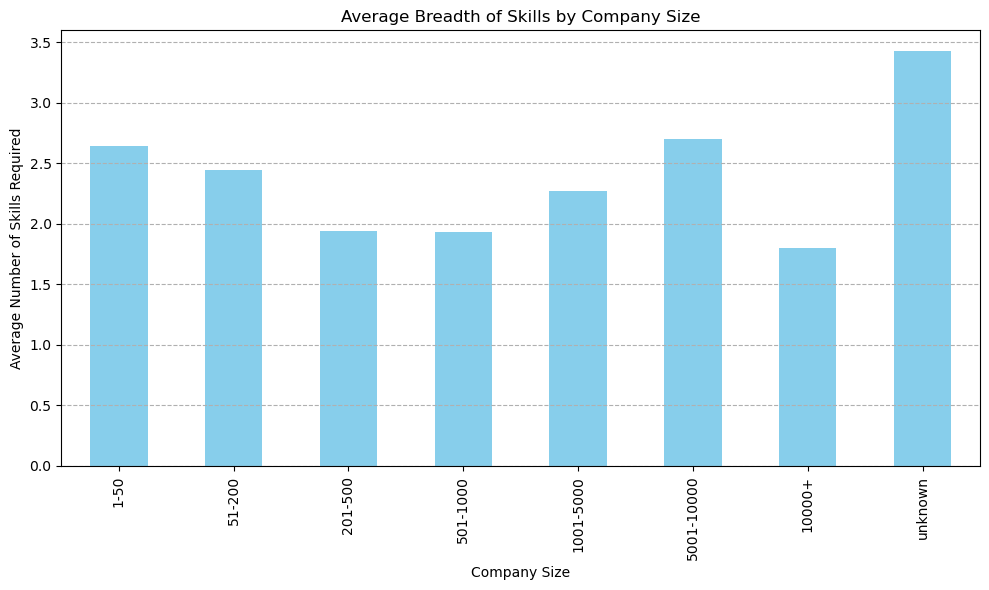

In [185]:
#Visualize the relationship using a bar chart
plt.figure(figsize=(10, 6))
size_skill_rel.plot(kind='bar', color='skyblue')
plt.title('Average Breadth of Skills by Company Size')
plt.xlabel('Company Size')
plt.ylabel('Average Number of Skills Required')
plt.xticks(rotation=90)
plt.grid(axis='y', linestyle='--')
plt.tight_layout()
plt.show()

In [190]:
# Group by company industry and calculate the average skill count
industry_skill_rel = company_char.groupby("industry")["skill_count"].mean().sort_values(ascending=False)
print("Average number of skills required per company size:")
print(industry_skill_rel)

Average number of skills required per company size:
industry
Publishing                               5.000000
Telecommunications Services              4.555556
TV Broadcast & Cable Networks            4.500000
Video Games                              4.166667
Cable, Internet & Telephone Providers    4.000000
                                           ...   
Food & Beverage Manufacturing            0.833333
Transportation Management                0.500000
Telecommunications Manufacturing         0.333333
Miscellaneous Manufacturing              0.000000
Trucking                                 0.000000
Name: skill_count, Length: 76, dtype: float64


In [191]:
# Visualize the top 5 most frequent combinations and their average salaries
top_5_industry = industry_skill_rel.head(5).reset_index()
top_5_industry

,industry,skill_count
0,Publishing,5.000000
1,Telecommunications Services,4.555556
2,TV Broadcast & Cable Networks,4.500000
3,Video Games,4.166667
4,"Cable, Internet & Telephone Providers",4.000000


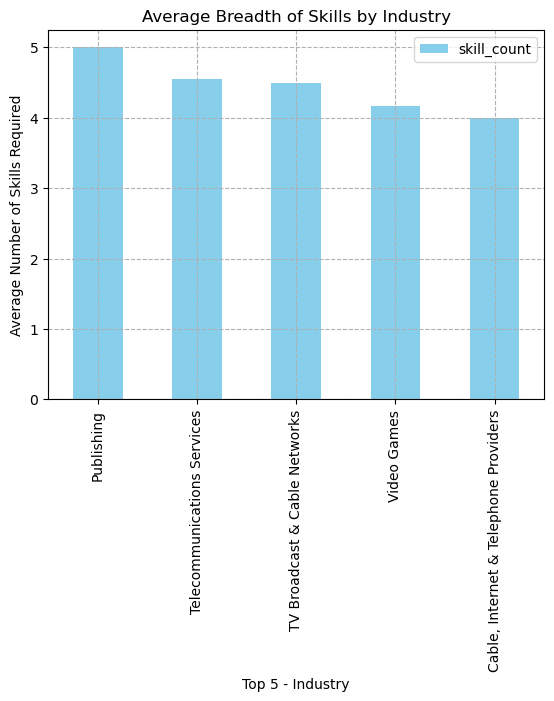

In [ ]:
#Visualize the relationship using a bar chart
top_5_industry.plot(kind='bar', x='industry', y='skill_count', color='skyblue')
plt.title('Average Breadth of Skills by Industry')
plt.xlabel('Top 5 - Industry')
plt.ylabel('Average Number of Skills Required')
plt.xticks(rotation=90)
plt.grid(linestyle='--')
plt.show()

In [174]:
### 2. Most frequent skill combinations and their average salary
#Identify job postings with overlapping skill requirements (more than one skill)
overlapping_skills_df = company_char[company_char['skill_count'] > 1].copy()

In [175]:
from itertools import combinations

In [176]:
# Function to generate all skill combinations for each job posting
def get_skill_combinations(row):
    active_skills = [skill for skill in skill_cols if row[skill] == 1]
    return list(combinations(active_skills, 2))  # Get combinations of size 2

In [177]:
# Apply the function and expand the list of combinations into a new DataFrame
overlapping_skills_df['combinations'] = overlapping_skills_df.apply(get_skill_combinations, axis=1)
expanded_combinations = overlapping_skills_df.explode('combinations')

In [179]:
# Group by combinations and calculate the count and average salary
combination_analysis = expanded_combinations.groupby('combinations').agg(
    count=('company name', 'size'),
    avg_salary=('avg_salary', 'mean')
).sort_values(by='count', ascending=False)

print("\nMost frequent skill combinations and their average salary:")
print(combination_analysis)


Most frequent skill combinations and their average salary:
                   count  avg_salary
combinations                        
(python, excel)      398  121.878788
(python, spark)      286  125.680556
(python, aws)        253  116.921875
(python, hadoop)     213  127.539130
(python, tableau)    191  125.373626
...                  ...         ...
(keras, mongo)         3         NaN
(aws, sas)             3         NaN
(scikit, flink)        2         NaN
(sas, pytorch)         1         NaN
(flink, mongo)         1         NaN

[65 rows x 2 columns]


In [199]:
# Visualize the top 5 most frequent combinations and their average salaries
top_10_combinations = combination_analysis.head(10).reset_index()
top_10_combinations

,combinations,count,avg_salary
0,"(python, excel)",398,121.878788
1,"(python, spark)",286,125.680556
2,"(python, aws)",253,116.921875
3,"(python, hadoop)",213,127.539130
4,"(python, tableau)",191,125.373626
5,"(hadoop, spark)",188,127.081633
6,"(excel, tableau)",167,122.739130
7,"(excel, aws)",161,119.861111
8,"(spark, aws)",150,118.323944
9,"(excel, spark)",147,125.044776


In [200]:
top_10_combinations['combinations_str'] = top_10_combinations['combinations'].apply(
    lambda x: ' + '.join(x)
)

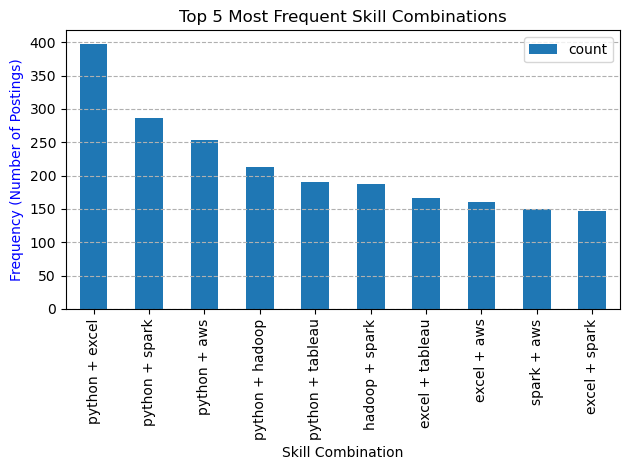

In [201]:
# Create bar chart for frequency (count)
top_10_combinations.plot(kind="bar", x='combinations_str', y='count')
plt.title('Top 5 Most Frequent Skill Combinations')
plt.xlabel('Skill Combination')
plt.ylabel('Frequency (Number of Postings)', color='blue')
plt.xticks(rotation=90)
plt.grid(axis='y', linestyle='--')
plt.tight_layout()
plt.show()


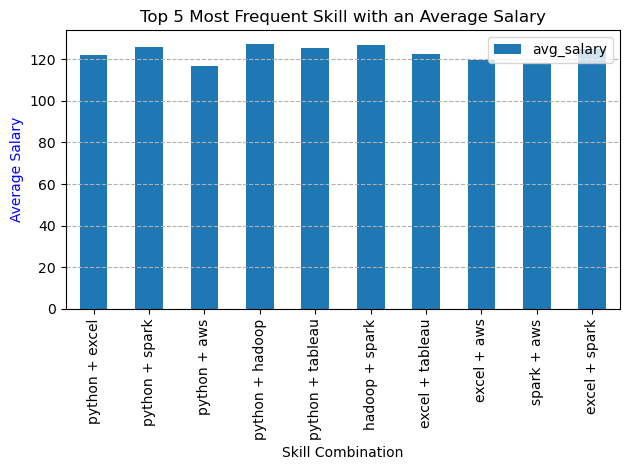

In [202]:
# Create bar chart for frequency (count)
top_10_combinations.plot(kind="bar", x='combinations_str', y='avg_salary')
plt.title('Top 5 Most Frequent Skill with an Average Salary')
plt.xlabel('Skill Combination')
plt.ylabel('Average Salary', color='blue')
plt.xticks(rotation=90)
plt.grid(axis='y', linestyle='--')
plt.tight_layout()
plt.show()